# ETH 3m short pilot v1 causal replay

## tl;dr

Strict OOS fired on **772/774** bars (99.74%). After 18-bar dedup, net 3h short return was **-31.97bp** versus matched random **-31.17bp**. The detector fails the density gate and should not enter the judgment layer.

## Context & Methods

Decision: whether the dedicated ETH 3m short detector is sparse and selective enough to justify building a judgment layer. Strict OOS is primary; pixel-disjoint interleaved gaps are diagnostic only. Entry is next-bar open, exit is the 60th 3m close, cost is 20bp.

### Key Assumptions

- No bar at or after 2026-05-04 is read.
- Every replay image has zero OHLC-bar overlap with all train/val images.
- Matched controls share untouched run and ATR quintile.

In [1]:
from pathlib import Path
import json, pandas as pd, numpy as np, matplotlib.pyplot as plt
PROJECT = Path.cwd()
OUT = PROJECT / 'analysis/output/eth3m_short_pilot_v1_backtest'
summary = json.loads((OUT / 'summary.json').read_text())
validation = json.loads((OUT / 'validation.json').read_text())
eligible = pd.read_csv(OUT / 'eligible.csv')
scan = pd.read_csv(OUT / 'scan_rows.csv')
signals = pd.read_csv(OUT / 'signals.csv')
controls = pd.read_csv(OUT / 'matched_controls.csv')
daily = pd.read_csv(OUT / 'daily.csv')
assert validation['status'] == 'pass'
print(f"validation={validation['status']} eligible={len(eligible)} scan={len(scan)} signals={len(signals)} controls={len(controls)}")

validation=pass eligible=5398 scan=5398 signals=347 controls=1039


## Data

The checks below verify population, temporal boundaries, and saved-output grain.

In [2]:
print('strict eligible:', int(eligible.strict_oos.sum()))
print('zero-overlap rows:', int((eligible.train_pixel_overlap_bars == 0).sum()))
print('raw fire:', int(scan.raw_fire.sum()), '/', len(scan))
print('mapped offsets:', (scan.loc[scan.raw_fire, 'bar_i'] - scan.loc[scan.raw_fire, 'mapped_box_bar_i']).value_counts().to_dict())
print('failed validation checks:', validation['failed'])

strict eligible: 774
zero-overlap rows: 5398
raw fire: 5071 / 5398
mapped offsets: {0: 5071}
failed validation checks: []


## Results

Strict OOS and the wider gap replay point in the same direction.

In [3]:
rows=[]
for scope,label in [('strict_oos','Strict OOS'),('gap_replay','Gap replay')]:
    r=summary['replay'][scope]
    rows.append({'scope':label,'eligible':r['eligible_bars'],'fire_rate_pct':100*r['raw_fire_rate'],'signals':r['dedup_signals'],'signals_day':r['dedup_signals_per_day'],'model_net_bp':1e4*r['net_mean_at_20bp'],'control_net_bp':1e4*r['matched_control_net_mean_at_20bp'],'excess_bp':1e4*r['paired_excess_mean'],'net_win_pct':100*r['net_win_rate_at_20bp']})
result_table=pd.DataFrame(rows)
print(result_table.round(2).to_string(index=False))

     scope  eligible  fire_rate_pct  signals  signals_day  model_net_bp  control_net_bp  excess_bp  net_win_pct
Strict OOS       774          99.74       43        26.67        -31.97          -31.17      -0.80        11.63
Gap replay      5398          93.94      304        27.03        -45.15          -40.71      -4.43        15.46


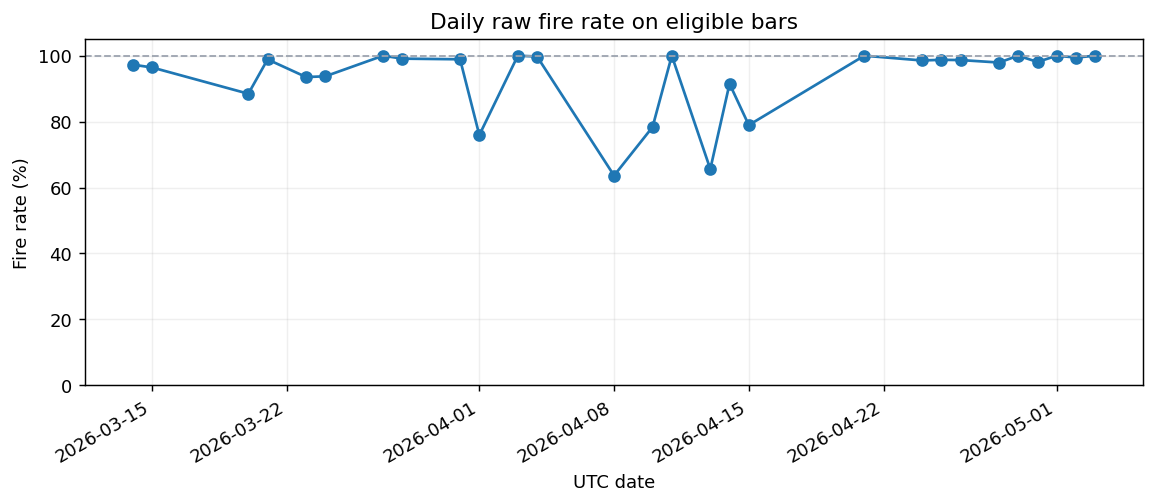

In [4]:
fig,ax=plt.subplots(figsize=(9,4))
ax.plot(pd.to_datetime(daily.date), daily.raw_fire_rate*100, marker='o', linewidth=1.5)
ax.axhline(100,color='#9ca3af',linestyle='--',linewidth=1)
ax.set(title='Daily raw fire rate on eligible bars',ylabel='Fire rate (%)',xlabel='UTC date',ylim=(0,105))
ax.grid(alpha=.2); fig.autofmt_xdate(); fig.tight_layout()

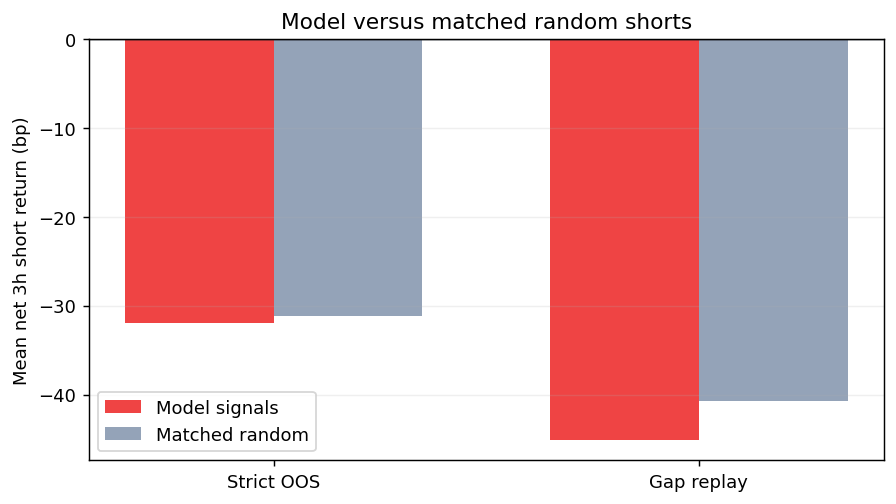

In [5]:
fig,ax=plt.subplots(figsize=(7,4))
x=np.arange(len(result_table)); width=.35
ax.bar(x-width/2,result_table.model_net_bp,width,label='Model signals',color='#ef4444')
ax.bar(x+width/2,result_table.control_net_bp,width,label='Matched random',color='#94a3b8')
ax.axhline(0,color='#111827',linewidth=.8)
ax.set_xticks(x,result_table.scope); ax.set_ylabel('Mean net 3h short return (bp)')
ax.set_title('Model versus matched random shorts'); ax.legend(); ax.grid(axis='y',alpha=.2); fig.tight_layout()

## Takeaways

- Strict OOS fire density is 99.74%, so 18-bar dedup is only a mechanical throttle.
- Strict matched excess is -0.80bp; gap matched excess is -4.43bp.
- Do not tune confidence on this replay or build the judgment layer. Rebuild v2 with sequence-local hard negatives and reserve a new continuous OOS block first.